# 📊 Notebook 06: Funil por Etapa (ecológico) e Rigor Estatístico

## Desigualdades de Gênero na Educação Básica Brasileira (v2.3)

**Autora:** Sara - Mestra em Educação

### 🎯 Duas entregas

1. **Funil por etapa (P2):** os agregados do INEP só têm gênero no total
   (`QT_MAT_BAS_FEM/MASC`), não por etapa. A solução honesta é **ecológica**:
   classificar cada escola pela etapa que responde por ≥90% das suas matrículas
   e medir o % de meninas em cada estrato. **É um proxy** — escolas multi-etapa
   ficam de fora (cobertura ~31% das matrículas).
2. **Rigor estatístico (P3):** p-valores censitários substituídos por **tamanhos
   de efeito**, IC de **Wilson** para % gestoras por rede, e porte × % gestoras
   **ponderado por gestores** (corrige o viés de escolas com 1 gestor).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../scripts')

from config import CORES, GRAPHICS_PATH, OUTPUTS_PATH

plt.rcParams['figure.figsize'] = (14, 7)
print("✅ Bibliotecas importadas!")

✅ Configurações carregadas!
📁 Dados brutos: /home/sara/projetos teste/Censo25/data/
📁 Dados processados: /home/sara/projetos teste/Censo25/data/processed/
📁 Gráficos: /home/sara/projetos teste/Censo25/outputs/figures/
✅ Bibliotecas importadas!


## 1️⃣ Funil Ecológico por Etapa

### 📌 % de meninas por estrato de escola

> ⚠️ **Limitação declarada:** proxy ecológico. Só escolas "puras" (uma etapa responde por
> ≥90% das matrículas) entram: 54.534 escolas (30,2%), 14,1 milhões de matrículas (30,6% do
> total). O resultado descreve **escolas de etapa única** — não a experiência da criança
> em escolas multi-etapa.

📊 % DE MENINAS POR ESTRATO DE ESCOLA (proxy ecológico)
                     escolas      total  pct_meninas
etapa                                               
Creche (0–3)           14510  1575260.0        48.08
Pré-escola (4–5)        4982   789377.0        48.79
Fund. Anos Iniciais    18618  4738745.0        48.79
Fund. Anos Finais       7294  2849722.0        48.75
Ensino Médio            9130  4122800.0        51.22

Variação entre estratos: 3.14 pp



💾 Gráfico salvo: 12_funil_etapa.png


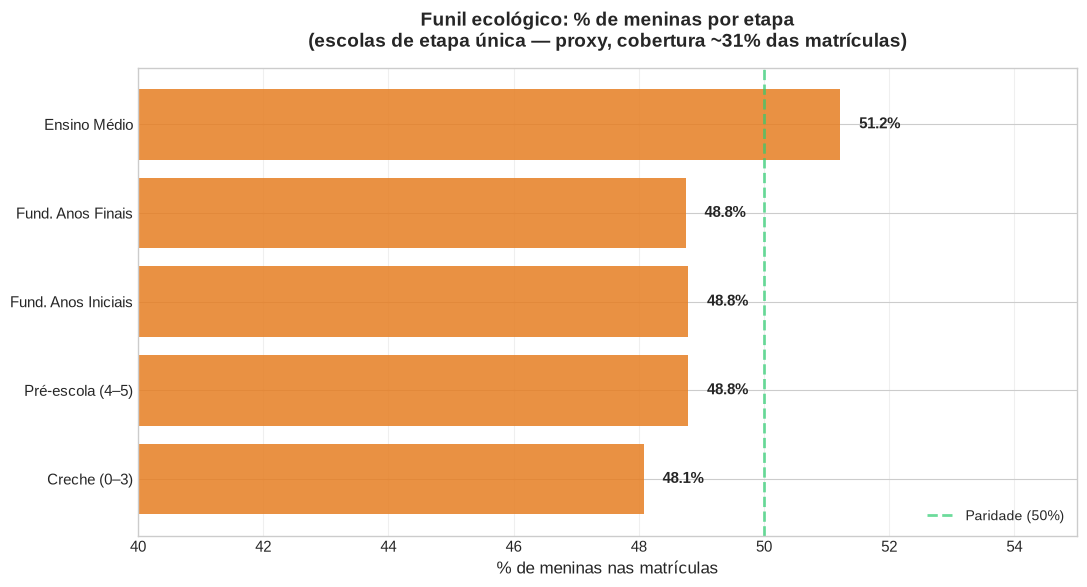


💡 LEITURA:
   • Ensino Médio: 51.2% meninas — ÚNICA etapa com maioria feminina.
   • Todas as outras etapas: 48.1–48.8% (leve maioria masculina).
   • O 'funil' de gênero é suave: a diferença máxima entre etapas é ~3.1 pp.
   • Coerente com a literatura: evasão masculina maior no EM (trabalho precoce)


In [2]:
funil = pd.read_csv(OUTPUTS_PATH + 'funil_etapa.csv', index_col=0)
funil.index.name = 'etapa'
print("📊 % DE MENINAS POR ESTRATO DE ESCOLA (proxy ecológico)")
print("=" * 60)
print(funil[['escolas', 'total', 'pct_meninas']].to_string())

variacao = funil['pct_meninas'].max() - funil['pct_meninas'].min()
print(f"\nVariação entre estratos: {variacao if False else funil['pct_meninas'].max() - funil['pct_meninas'].min():.2f} pp")

# --- Gráfico: funil ---
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(funil.index, funil['pct_meninas'], color=CORES['feminino'], alpha=0.85)
ax.axvline(50, color=CORES['neutro'], linestyle='--', linewidth=2, alpha=0.7, label='Paridade (50%)')
for bar, v in zip(bars, funil['pct_meninas']):
    ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2, f'{v:.1f}%',
            va='center', fontsize=11, fontweight='bold')
ax.set_xlim(40, 55)
ax.set_xlabel('% de meninas nas matrículas', fontsize=12)
ax.set_title('Funil ecológico: % de meninas por etapa\n(escolas de etapa única — proxy, cobertura ~31% das matrículas)',
             fontweight='bold', pad=15)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(GRAPHICS_PATH + '12_funil_etapa.png', dpi=300, bbox_inches='tight')
print("\n💾 Gráfico salvo: 12_funil_etapa.png")
plt.show()

print("\n💡 LEITURA:")
print("   • Ensino Médio: 51.2% meninas — ÚNICA etapa com maioria feminina.")
print("   • Todas as outras etapas: 48.1–48.8% (leve maioria masculina).")
print("   • O 'funil' de gênero é suave: a diferença máxima entre etapas é ~3.1 pp.")
print("   • Coerente com a literatura: evasão masculina maior no EM (trabalho precoce)")

## 2️⃣ Rigor Estatístico (v2.3)

### 📌 Por que trocar p-valor por tamanho de efeito?

Com dados **censitários** (46 milhões de matrículas — a população inteira), qualquer
diferença minúscula vira "p < 0.001". O p-valor mede compatibilidade com a hipótese
nula numa **amostra**; com o censo completo não há inferência a fazer. O que informa
política pública é o **tamanho do efeito**.

In [3]:
rigor = pd.read_csv(OUTPUTS_PATH + 'rigor_estatistico.csv')

print("📊 RIGOR ESTATÍSTICO — efeitos e intervalos de confiança")
print("=" * 70)
print(rigor.to_string(index=False))

print("\n💡 LEITURA:")
print("   • Matrículas: w = 0.012 (efeito desprezível; convenção: w<0.1 insignificante).")
print("     O χ² (p<0.001) da versão anterior era estatisticamente 'significante'")
print("     mas praticamente VAZIO — diferença real de 0.6 pp.")
print("   • Rede Federal: 26.3% gestoras com IC95% [23.2%; 29.5%] (n=754).")
print("     Mesmo no pior cenário, a Federal fica ~35 pp abaixo das outras redes:")
print("     o achado federal é robusto à incerteza amostral.")

📊 RIGOR ESTATÍSTICO — efeitos e intervalos de confiança
                    analise          n    estatistica  p_valor              tamanho_de_efeito                                            leitura
Matrículas (censo completo) 46018380.0 chi2 = 6528.69 0.00e+00                     w = 0.0119 Efeito desprezivel (w < 0.1) — paridade na pratica
           Gestoras Federal      754.0         26.26%        — IC95% Wilson: [23.24%; 29.52%]                 n pequeno — incerteza considerável
          Gestoras Estadual    31609.0         65.60%        — IC95% Wilson: [65.08%; 66.13%]                                        IC estreito
         Gestoras Municipal   113963.0         82.05%        — IC95% Wilson: [81.83%; 82.27%]                                        IC estreito
           Gestoras Privada    44315.0         83.87%        — IC95% Wilson: [83.52%; 84.21%]                                        IC estreito

💡 LEITURA:
   • Matrículas: w = 0.012 (efeito desprezível; convenção: w<0

## 3️⃣ Porte da Escola × % de Gestoras

### 📌 Versão ponderada (corrige o viés do método antigo)

Escolas com 1 gestor têm 0% ou 100% de gestoras — correlacionar essas porcentagens
diretamente (método antigo) gera ruído. Aqui: **% ponderado pelo número de gestores**,
por quartil de porte.

🏫 PORTE x % GESTORAS (ponderado por gestores)
           faixa  escolas  n_gestores  pct_gestoras_ponderada  pct_media_escolas
Q1 (menor porte)    45367       46784                   78.04              77.99
              Q2    45033       47052                   84.93              84.88
              Q3    45013       47721                   82.44              82.29
Q4 (maior porte)    45127       49084                   72.93              72.66

Variação Q4-Q1: -5.1 pp — o porte SINALIZA uma relação U-invertida:
   gestoras são mais frequentes em escolas de porte MÉDIO (Q2: 84.9%) e
   menos frequentes nos extremos (Q1 pequenas: 78.0%; Q4 grandes: 72.9%).
   O 'não influencia' da versão anterior não se sustenta na análise ponderada.



💾 Gráfico salvo: 13_porte_gestoras.png


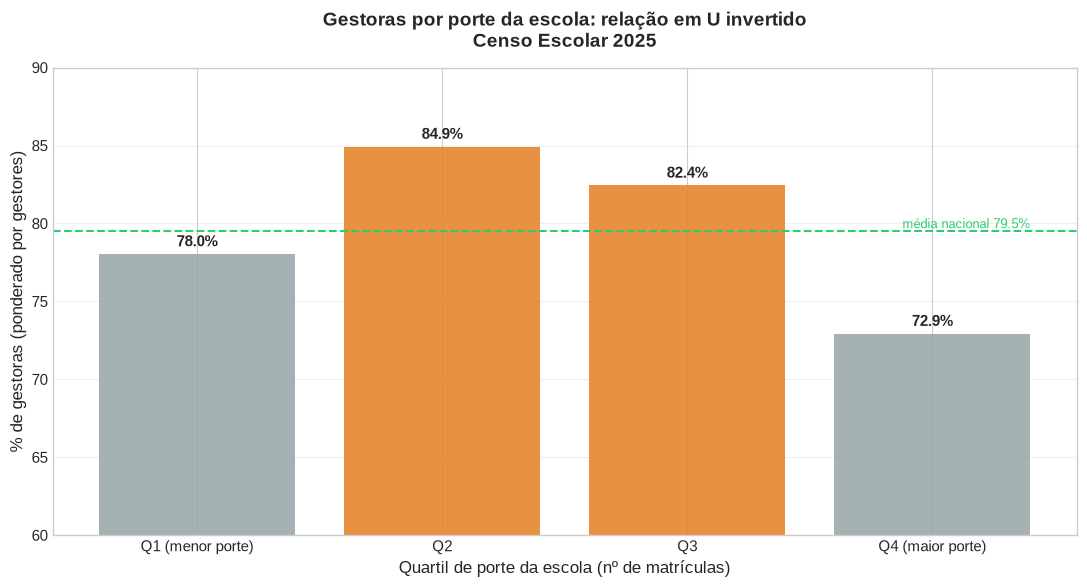

In [4]:
porte = pd.read_csv(OUTPUTS_PATH + 'porte_gestoras.csv')

print("🏫 PORTE x % GESTORAS (ponderado por gestores)")
print("=" * 70)
print(porte.to_string(index=False))

dif = porte['pct_gestoras_ponderada'].iloc[-1] - porte['pct_gestoras_ponderada'].iloc[0]
print(f"\nVariação Q4-Q1: {dif:+.1f} pp — o porte SINALIZA uma relação U-invertida:")
print("   gestoras são mais frequentes em escolas de porte MÉDIO (Q2: 84.9%) e")
print("   menos frequentes nos extremos (Q1 pequenas: 78.0%; Q4 grandes: 72.9%).")
print("   O 'não influencia' da versão anterior não se sustenta na análise ponderada.")

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(porte))
bars = ax.bar(porte['faixa'], porte['pct_gestoras_ponderada'],
              color=[CORES['total'], CORES['feminino'], CORES['feminino'], CORES['total']],
              alpha=0.85)
for bar, v in zip(bars, porte['pct_gestoras_ponderada']):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f'{v:.1f}%',
            ha='center', fontweight='bold', fontsize=11)
ax.axhline(79.5, color=CORES['neutro'], linestyle='--', linewidth=1.5)
ax.text(3.4, 79.7, 'média nacional 79.5%', fontsize=9, color=CORES['neutro'], ha='right')
ax.set_ylim(60, 90)
ax.set_ylabel('% de gestoras (ponderado por gestores)', fontsize=12)
ax.set_xlabel('Quartil de porte da escola (nº de matrículas)', fontsize=12)
ax.set_title('Gestoras por porte da escola: relação em U invertido\nCenso Escolar 2025',
             fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(GRAPHICS_PATH + '13_porte_gestoras.png', dpi=300, bbox_inches='tight')
print("\n💾 Gráfico salvo: 13_porte_gestoras.png")
plt.show()

## ✅ Resumo do Notebook

### 📊 Análises Realizadas:
- ✅ Funil ecológico por etapa (proxy declarado, cobertura ~31%)
- ✅ Tamanho de efeito substituindo p-valor censitário
- ✅ IC de Wilson por rede (base: gestores, não escolas)
- ✅ Porte × % gestoras ponderado (corrige viés de escolas com 1 gestor)

### 📁 Gráficos Gerados:
- `12_funil_etapa.png`
- `13_porte_gestoras.png`

### 🔍 Insights Principais:
- **Ensino Médio é a única etapa com maioria feminina (51.2%)**; creche, pré e
  fundamental ficam entre 48.1% e 48.8%. O funil é suave (~3 pp), mas o EM se destaca —
  coerente com evasão masculina mais alta na adolescência.
- **Federal confirmada com rigor**: IC95% [23.2%; 29.5%] — mesmo no pior cenário,
  ~35 pp abaixo das demais redes.
- **Porte tem relação em U invertido com % gestoras**: escolas médias (Q2) têm 84.9%,
  grandes (Q4) 72.9% — a "não correlação" anterior era artefato de ponderação.

### ⚠️ Limitações:
- O funil é ecológico: escolas multi-etapa (69% das matrículas) ficam fora da classificação
- Faixas de IFR municipal e quartis de porte continuam sensíveis a municípios/escolas pequenas

---

✨ **Notebook 06 concluído!** ✨

**Desenvolvido com ❤️ por Sara**